## HOTEL RESERVATION CANCELLATION PREDICTION

The aim of this project is to predict the possible reservations that are going to be cancelled by the customers by analyzing various features and variables associated with the reservation.

### Context
The online hotel reservation channels have dramatically changed booking possibilities and customers’ behavior. A significant number of hotel reservations are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with.

### Data Dictionary

| Column Name | Description |
| --- | --- |
|Booking_ID|unique identifier of each booking|
|no_of_adults|number of adults|
|no_of_children|number of children|
|no_of_weekend_nights|number of weekend nights  (Saturday or Sunday) the guest stayed or booked to stay at the hotel|
|no_of_week_nights|number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel|
|meal_type|meal type booked by the customer|
|required_car_parking_spaces| Does the customer require a car parking space? (0 - No, 1- Yes)|
|lead_time|Number of days between the date of booking and the arrival date|
|arrival_year|Year of arrival|
|arrival_month|Month of arrival|
|arrival_date|Date of arrival|
|market_segment|Market segment designation|
|repeated_guest | Is the customer a repeated guest? (0 - No, 1- Yes) |
|no_previous_cancellations| Number of previous bookings that were canceled by the customer prior to the current booking|
|previous_bookings_not_canceled|Number of previous bookings not canceled by the customer prior to the current booking|
|avg_price_per_room|Average price per day of the reservation; prices of the rooms are dynamic. (in euros)|
|no_of_special_requests|Total number of special requests made by the customer (e.g. high floor, view from the room, etc)|
|booking_status|Flag indicating if the booking was canceled or not|

Import Libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the data. 

In [2]:
df =pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### Data preprocessing Part 1

In [3]:
# checking the shape of the dataset 
df.shape

(36275, 19)

In [4]:
## dropping booking_ID
df.drop(columns='Booking_ID',axis=1, inplace=True)

In [5]:
## checking the information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  object 
 5   required_car_parking_space            36275 non-null  int64  
 6   room_type_reserved                    36275 non-null  object 
 7   lead_time                             36275 non-null  int64  
 8   arrival_year                          36275 non-null  int64  
 9   arrival_month                         36275 non-null  int64  
 10  arrival_date                          36275 non-null  int64  
 11  market_segment_

checking missing data

In [6]:
df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [7]:
df.dtypes

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

### Features Handling

In [8]:
## combining the column arrival_date, month, and year into a single column. yyy/mmm/ddd
df['date of arrival'] = df['arrival_year'].astype(str) + '/' + df['arrival_month'].astype(str) + '/' + df['arrival_date'].astype(str) 

# type cast 
df['date of arrival'] = pd.to_datetime(df['date of arrival'], format='mixed', errors='coerce', yearfirst=True)

# dropping the merged column
df.drop(columns=['arrival_date', 'arrival_month', 'arrival_year'], inplace=True)

# check missing value in the new column
df.isna().sum()

# drop missing value in the new column 
df.dropna(inplace=True)
df.reset_index()

# confirm new column data type
df.dtypes

no_of_adults                                     int64
no_of_children                                   int64
no_of_weekend_nights                             int64
no_of_week_nights                                int64
type_of_meal_plan                               object
required_car_parking_space                       int64
room_type_reserved                              object
lead_time                                        int64
market_segment_type                             object
repeated_guest                                   int64
no_of_previous_cancellations                     int64
no_of_previous_bookings_not_canceled             int64
avg_price_per_room                             float64
no_of_special_requests                           int64
booking_status                                  object
date of arrival                         datetime64[ns]
dtype: object

Check for unique values in the columns. 

In [9]:
df.nunique()

no_of_adults                               5
no_of_children                             6
no_of_weekend_nights                       8
no_of_week_nights                         18
type_of_meal_plan                          4
required_car_parking_space                 2
room_type_reserved                         7
lead_time                                352
market_segment_type                        5
repeated_guest                             2
no_of_previous_cancellations               9
no_of_previous_bookings_not_canceled      59
avg_price_per_room                      3919
no_of_special_requests                     6
booking_status                             2
date of arrival                          549
dtype: int64

In [10]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,date of arrival
count,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238.000000,36238
mean,1.845301,0.105221,0.810475,2.204206,0.030934,85.275070,0.025553,0.023346,0.152961,103.437259,0.619957,2018-05-24 16:37:29.130746880
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017-07-01 00:00:00
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000,2018-02-28 00:00:00
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000,2018-06-12 00:00:00
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000,2018-09-19 00:00:00
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000,2018-12-31 00:00:00
std,0.518572,0.402540,0.870992,1.410784,0.173142,85.953561,0.157801,0.368483,1.753366,35.084264,0.786403,NaN


In [11]:
df['avg_price_per_room'].replace(0, df['avg_price_per_room'].mean(), inplace=True)
df.drop(df[df['no_of_adults'] == 0].index, inplace=True)

df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6876\2371348847.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['avg_price_per_room'].replace(0, df['avg_price_per_room'].mean(), inplace=True)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date of arrival
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,Canceled,2018-02-28
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,Canceled,2018-05-20
4,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,Canceled,2018-04-11


## Exploratory Data Analysis 

### Guest Information

Text(0.5, 1.0, 'No of children')

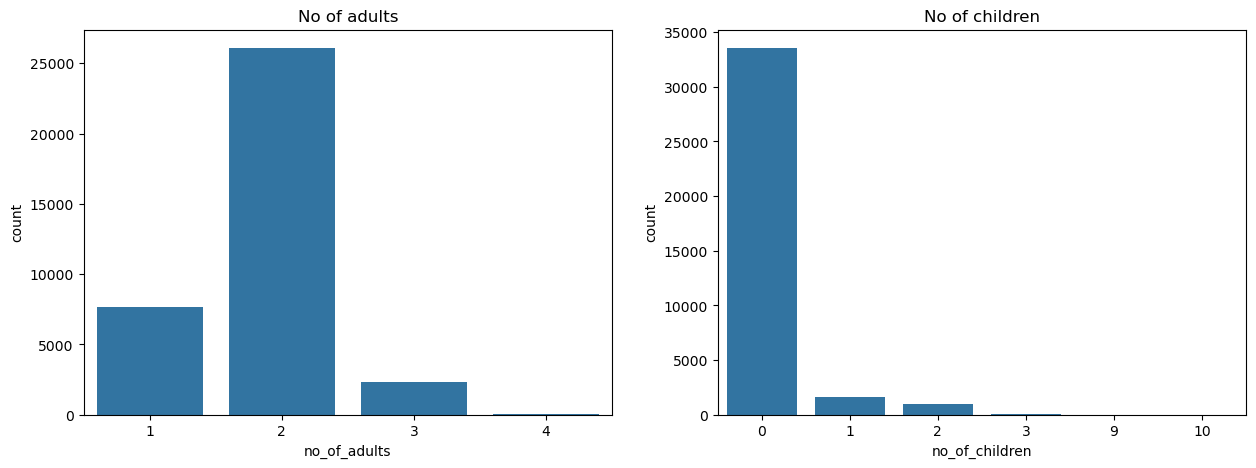

In [12]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x = 'no_of_adults', ax=ax[0]).set_title('No of adults')
sns.countplot(data=df, x = 'no_of_children', ax=ax[1]).set_title('No of children')

The plot shows that the Hotel is a couple destination with nearly 72% bookings made by couples and the secondly,single adults with no children probably for business trips making around 16% bookings

### Time spent at the Hotel

Text(0.5, 1.0, 'No of Week Nights')

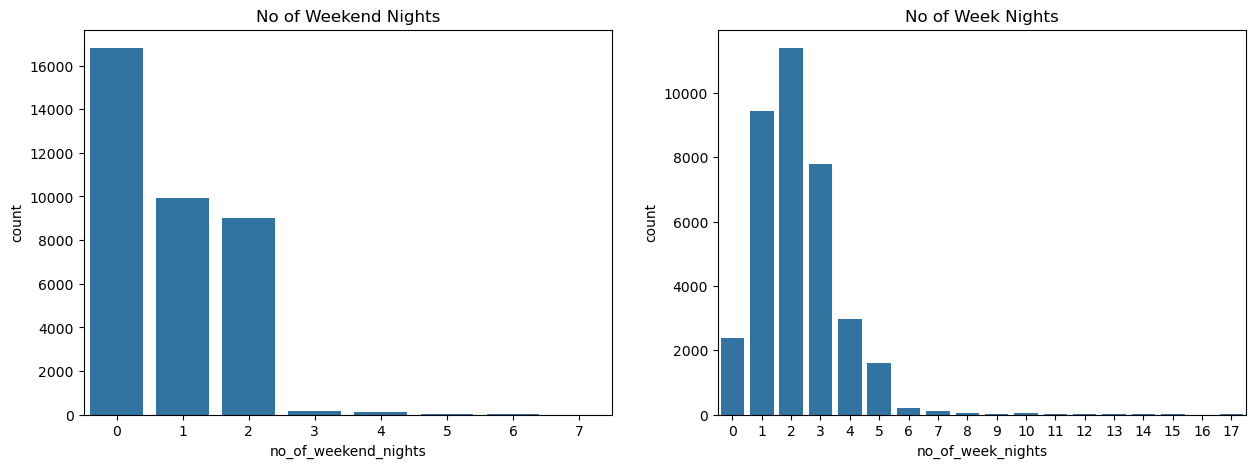

In [13]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x='no_of_weekend_nights', ax=ax[0]).set_title('No of Weekend Nights')
sns.countplot(data=df, x='no_of_week_nights', ax=ax[1]).set_title('No of Week Nights')

From this plot, most of the bookings were non weekend but most of the bookings were for week nights which assume that most of the bookings on week nights were for business trip and the ones for weekend were for vacations. 

### Date of Arrival 

Text(0.5, 1.0, 'Week of arrival')

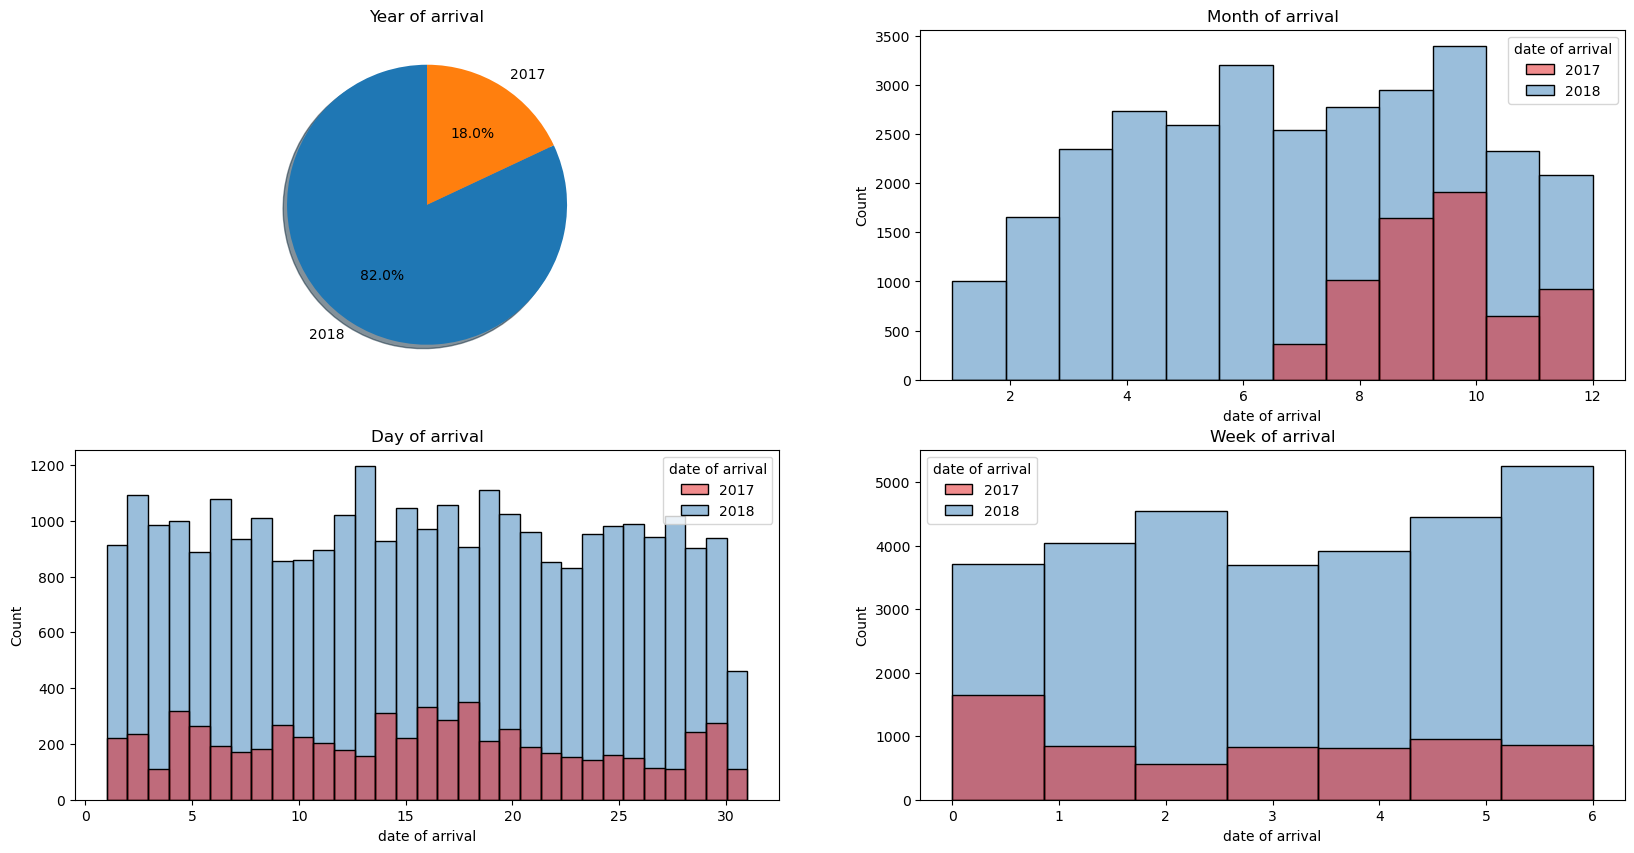

In [14]:
fig, ax = plt.subplots(2,2, figsize=(20,10))

# year of arrival 
year_counts = df['date of arrival'].dt.year.value_counts()

ax[0,0].pie(year_counts, labels=year_counts.index, autopct='%1.1f%%', shadow=True, startangle=90)
ax[0,0].set_title('Year of arrival')

# Month of arrival 
sns.histplot(data=df, x=df['date of arrival'].dt.month, ax=ax[0,1], bins=12, hue=df['date of arrival'].dt.year, palette='Set1').set_title('Month of arrival')

# Day of arrival 
sns.histplot(data=df, x=df['date of arrival'].dt.day, ax=ax[1,0], bins=31, hue=df['date of arrival'].dt.year, palette='Set1').set_title('Day of arrival')

# Week of arrival 
sns.histplot(data=df, x=df['date of arrival'].dt.dayofweek, ax=ax[1,1], bins=7, hue=df['date of arrival'].dt.year, palette='Set1').set_title('Week of arrival')

Booking data spans 2017-2018 with 82% of reservation coming from 2018. Peak season runs from August to November. The most of the guest that made reservation came early during the week. 

### Services

Text(0.5, 1.0, 'No_of_special_requests')

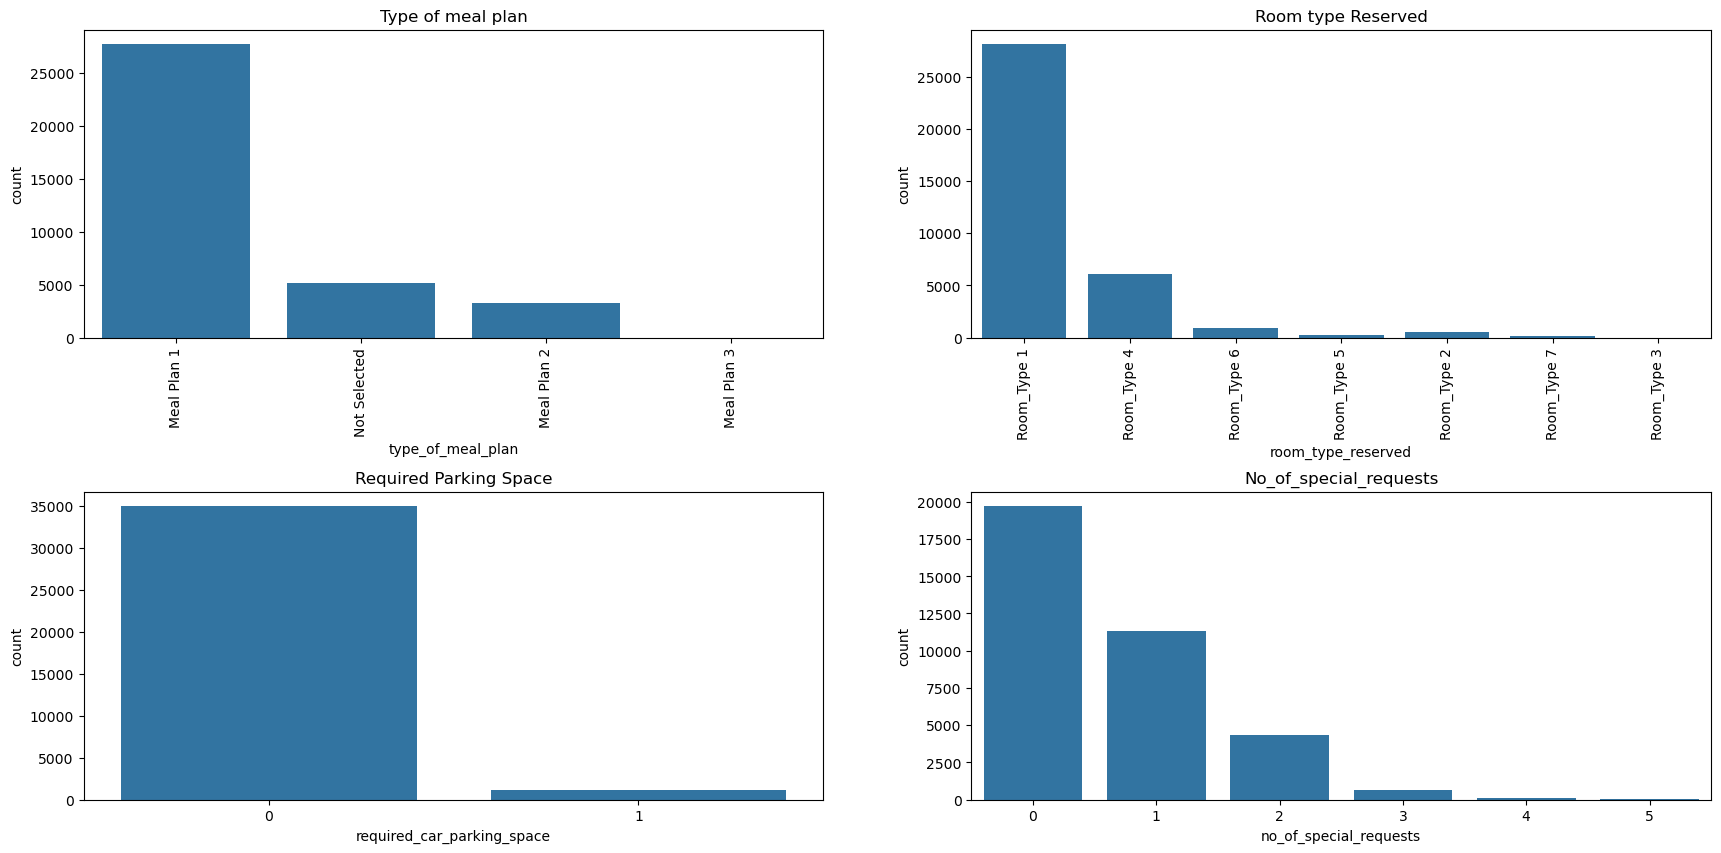

In [15]:
fig, ax = plt.subplots(2,2, figsize=(21,10))
fig.subplots_adjust(hspace=0.5)

# type of meal plan
sns.countplot(data=df, x='type_of_meal_plan', ax=ax[0,0]).set_title('Type of meal plan')
ax[0,0].xaxis.set_tick_params(rotation=90)

# room type
sns.countplot(data=df, x='room_type_reserved', ax=ax[0,1]).set_title('Room type Reserved')
ax[0,1].xaxis.set_tick_params(rotation=90)

# required parking space
sns.countplot(data=df, x='required_car_parking_space', ax=ax[1,0]).set_title('Required Parking Space')


# No of special request
sns.countplot(data=df, x='no_of_special_requests', ax=ax[1,1]).set_title('No_of_special_requests')

From the plot, we see that the meal type I was majorly preferred than any other meal type and with most of the guest not selecting any meal plan which suggest that they have their meal outside the Hotel services. Also, the room type 1 was the most wanted with room type 4 coming second. Most of the guest probably arrive in public transport which implies that most guest were likely out-of-town travelers. With no special request from the guest, this suggest that guest were maily there for business purpose and not for leisure purposes. 

### Lead time, i.e days between date of reservation and days of arrival 

Text(0.5, 1.0, 'Lead time in days')

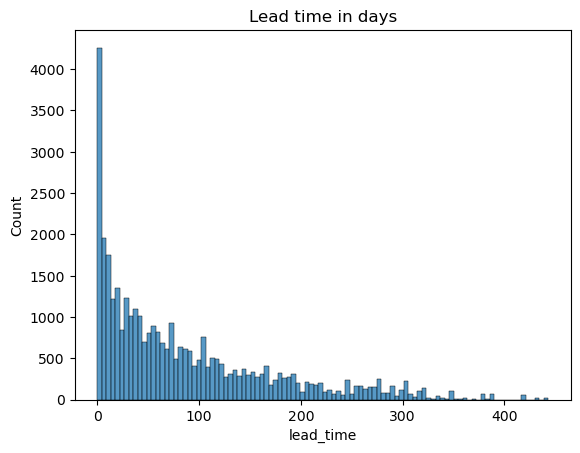

In [16]:
sns.histplot(data=df, x='lead_time', bins=100).set_title('Lead time in days')

Majority of the guests are last-minutes bookers, reserving within 20 days of arrival. This guest have the lowest cancellation risk because they are committed to their immediate plan. Lead time in the range of 100-400 days could be a demostration of long term events in advance like honeymoon. 

### Market Segment

Text(0.5, 1.0, 'Market segment type')

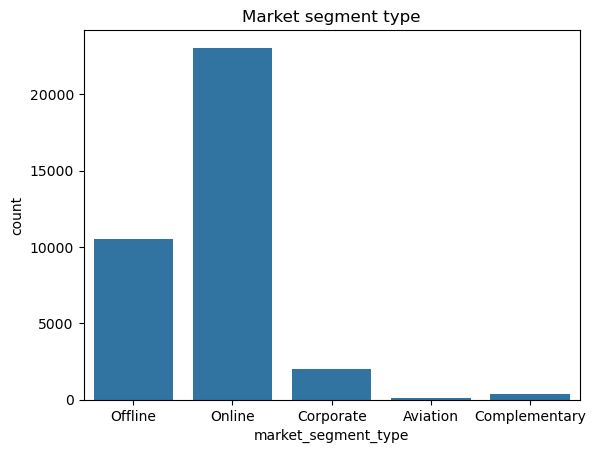

In [17]:
sns.countplot(data=df, x='market_segment_type').set_title('Market segment type')

Most of the reservations were made online which is a testament to the above assumption that guest were mainly in-town-travellers who mde their bookings along the way to the Hotel. While offilne bookings ranks seconds, this suggest few of the guest walk into the Hotel before making reservations. However, most of the cancellation might come from the online path while few cancellation would be made from offline since it takes more time to cancel physically than online.


### Guest previous experience with the hotel

Text(0.5, 1.0, 'No of previous bookings not canceled')

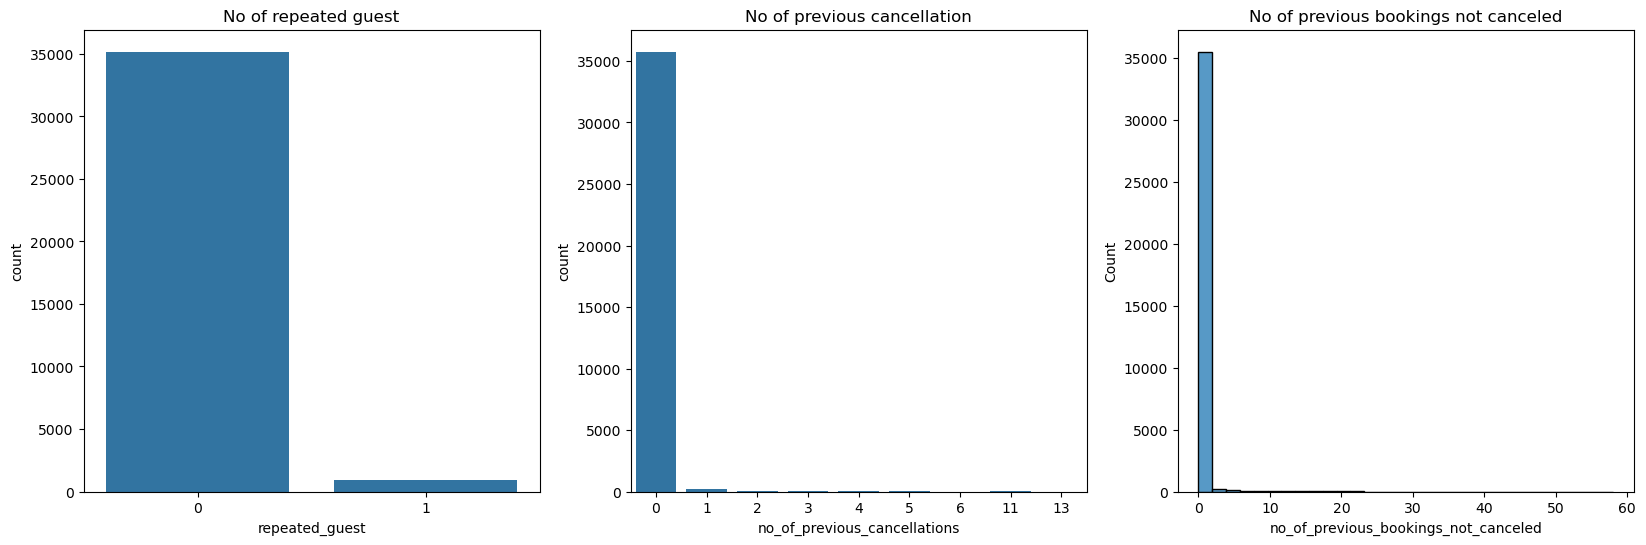

In [18]:
fig, ax = plt.subplots(1,3, figsize=(20,6))

# repeated guest
sns.countplot(data=df, x='repeated_guest', ax=ax[0]).set_title('No of repeated guest')

# previously cancelled bookings
sns.countplot(data=df, x='no_of_previous_cancellations', ax=ax[1]).set_title('No of previous cancellation')

# previously non-cancelled bookings 
sns.histplot(data=df, x='no_of_previous_bookings_not_canceled', ax=ax[2], bins=30).set_title('No of previous bookings not canceled')

Over 95% percent of the guest are first time visitor. Since guest are mostly first timers, there won't be record for cancellation and previous bookings cancelled. 

### Average room price 

Text(0.5, 1.0, 'Average price per room')

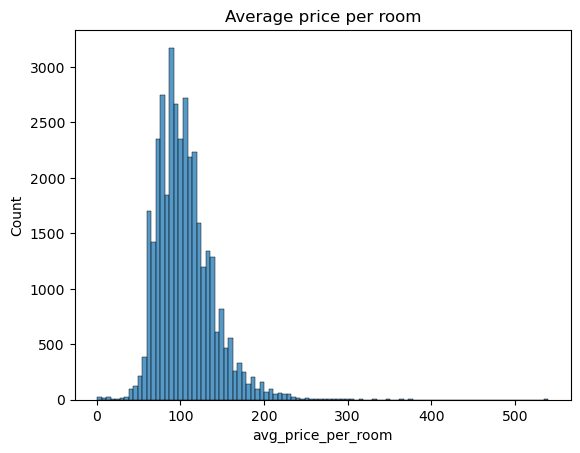

In [19]:
sns.histplot(data=df, x='avg_price_per_room', bins=100).set_title('Average price per room')

The majority of bookings are around $100 per night, consistent with our earlier findings that most of the guest were travelers and are not there for leisure but for work. This brings about the low budget price of the guest while rooms priced above $200 were probably for premium reasons, whether party and the likes.

## Independent variable vs target variable 

### Guest Inforamtion and cancellation

Text(0.5, 1.0, 'No of children')

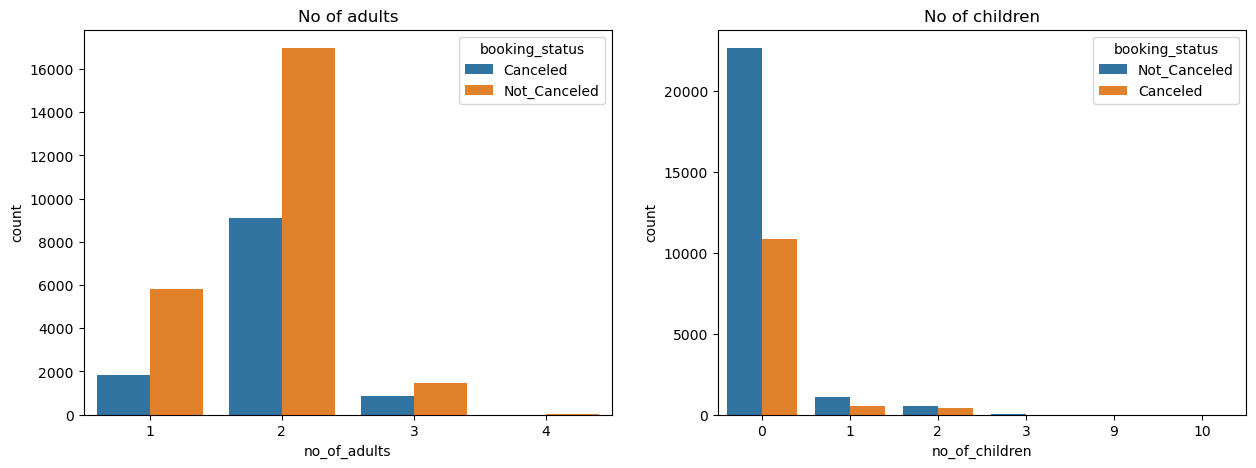

In [20]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x = 'no_of_adults', ax=ax[0], hue='booking_status').set_title('No of adults')
sns.countplot(data=df, x = 'no_of_children', ax=ax[1], hue='booking_status').set_title('No of children')

PLot shows that most of the guest that made bookings are actually solo adults with no children. They are probaby on a business trip that has all been planned and can't be overturned. Most of the couples that made bookings actually ended up canceling which occur from unplanned happenings most of the time.

## Time spent at the hotel vs cancellation

Text(0.5, 1.0, 'No of Week Nights')

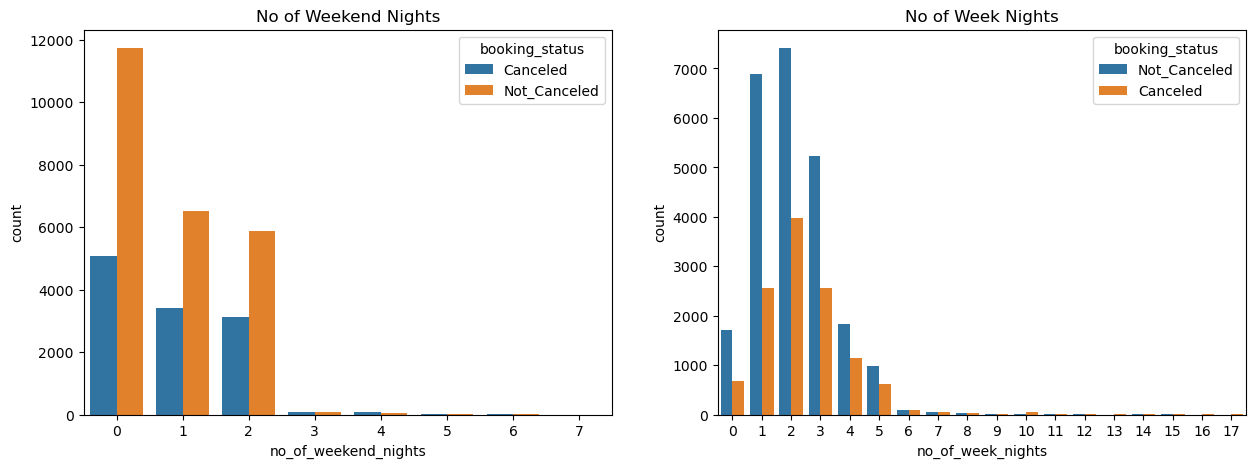

In [21]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x='no_of_weekend_nights', ax=ax[0], hue='booking_status').set_title('No of Weekend Nights')
sns.countplot(data=df, x='no_of_week_nights', ax=ax[1], hue='booking_status').set_title('No of Week Nights')

Guests booking longer weekday stays and are likely not to cancel their reservation. Guest who book no weekend night are also likey not cancel their reservation. This majorly occur due to the fact that the guests are travelers and are required to return to their place of work the next weekday.  

### Date of arrival vs cancellation

Text(0.5, 1.0, 'cancellation in week 2018')

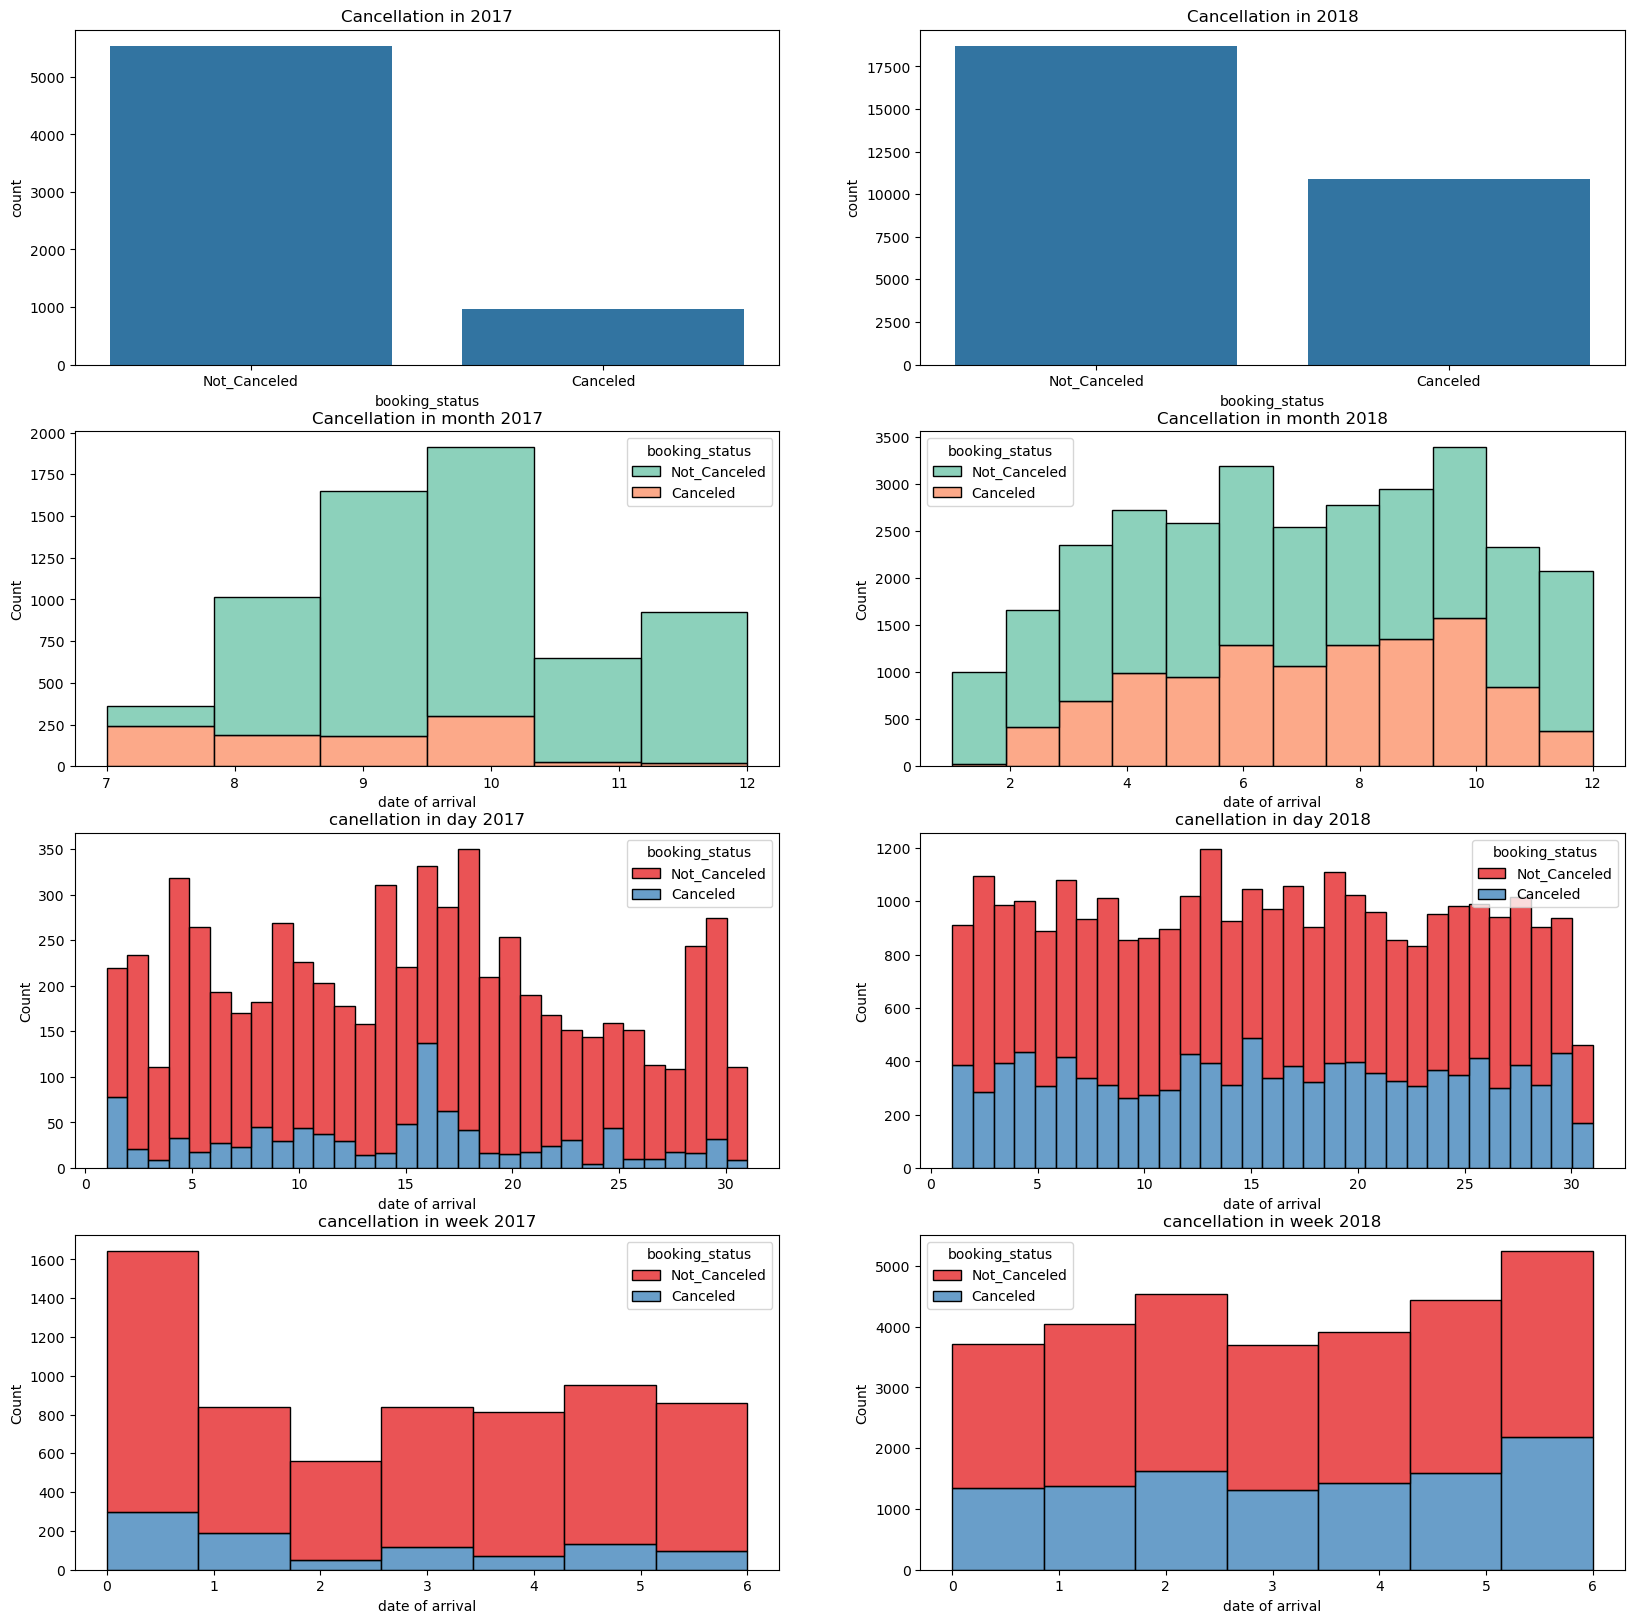

In [22]:
fig, ax = plt.subplots(4,2, figsize=(20,20))

 
df_2017 = df[df['date of arrival'].dt.year == 2017]
df_2018 = df[df['date of arrival'].dt.year == 2018]

# cancellation in years
sns.countplot(data=df, x=df_2017['booking_status'], ax=ax[0,0]).set_title('Cancellation in 2017')
sns.countplot(data=df, x=df_2018['booking_status'], ax=ax[0,1]).set_title('Cancellation in 2018')

# cancellation in months
sns.histplot(data=df, x=df_2017['date of arrival'].dt.month, ax=ax[1,0], bins=6, hue=df_2017['booking_status'], palette = 'Set2', multiple ='stack').set_title('Cancellation in month 2017')
sns.histplot(data=df, x=df_2018['date of arrival'].dt.month, ax=ax[1,1], bins=12, hue=df_2018['booking_status'], palette = 'Set2', multiple ='stack').set_title('Cancellation in month 2018')

# cancellation in days
sns.histplot(data=df, x=df_2017['date of arrival'].dt.day, ax=ax[2,0], bins=31, hue=df_2017['booking_status'], palette = 'Set1', multiple ='stack').set_title('canellation in day 2017')
sns.histplot(data=df, x=df_2018['date of arrival'].dt.day, ax=ax[2,1], bins=31, hue=df_2018['booking_status'], palette = 'Set1', multiple ='stack').set_title('canellation in day 2018')

# cancellation in weeks
sns.histplot(data=df, x=df_2017['date of arrival'].dt.dayofweek, ax=ax[3,0], bins=7, hue=df_2017['booking_status'], palette = 'Set1', multiple ='stack').set_title('cancellation in week 2017')
sns.histplot(data=df, x=df_2018['date of arrival'].dt.dayofweek, ax=ax[3,1], bins=7, hue=df_2018['booking_status'], palette = 'Set1', multiple ='stack').set_title('cancellation in week 2018')

Cancellation grew drastically from 2017 to 2018. Cancellation is very low in the month in 2017, but relaivley high from month 6 onward in 2018. Over day of arrival, cancellation didn't grow both in 2017 and 2018. In the week day, day 0 in 2017 has the highest number of bookings and cancellation, while in 2018, cancellation was relatively high in all days of the week and bookings were also high.

### Service and cancellation

Text(0.5, 1.0, 'No_of_special_requests vs cancellation')

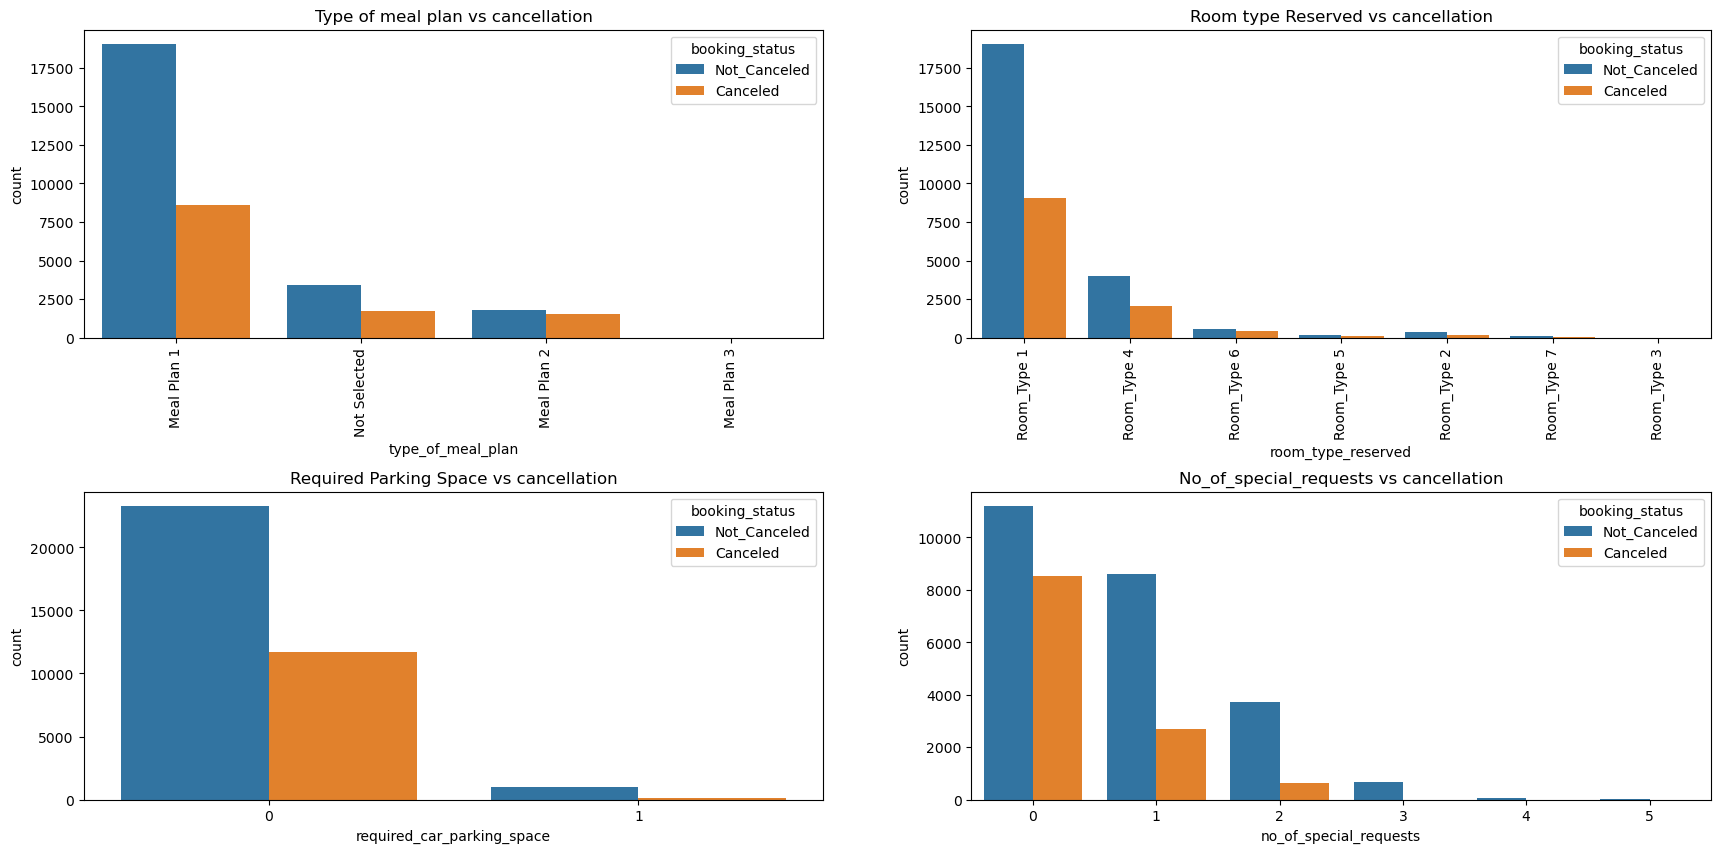

In [23]:
fig, ax = plt.subplots(2,2, figsize=(21,10))
fig.subplots_adjust(hspace=0.5)

# type of meal plan
sns.countplot(data=df, x='type_of_meal_plan', ax=ax[0,0], hue='booking_status').set_title('Type of meal plan vs cancellation')
ax[0,0].xaxis.set_tick_params(rotation=90)

# room type
sns.countplot(data=df, x='room_type_reserved', ax=ax[0,1], hue='booking_status').set_title('Room type Reserved vs cancellation')
ax[0,1].xaxis.set_tick_params(rotation=90)

# required parking space
sns.countplot(data=df, x='required_car_parking_space', ax=ax[1,0], hue='booking_status').set_title('Required Parking Space vs cancellation')


# No of special request
sns.countplot(data=df, x='no_of_special_requests', ax=ax[1,1], hue='booking_status').set_title('No_of_special_requests vs cancellation')

Cancellation naturally concentrate in the most popular total bookings. Guest who select no meal plan have higher chances of canceling. Guest with one or more special request are less likely to cancel.

### Lead time and cancellation

Text(0.5, 1.0, 'Lead time in days vs cancellation')

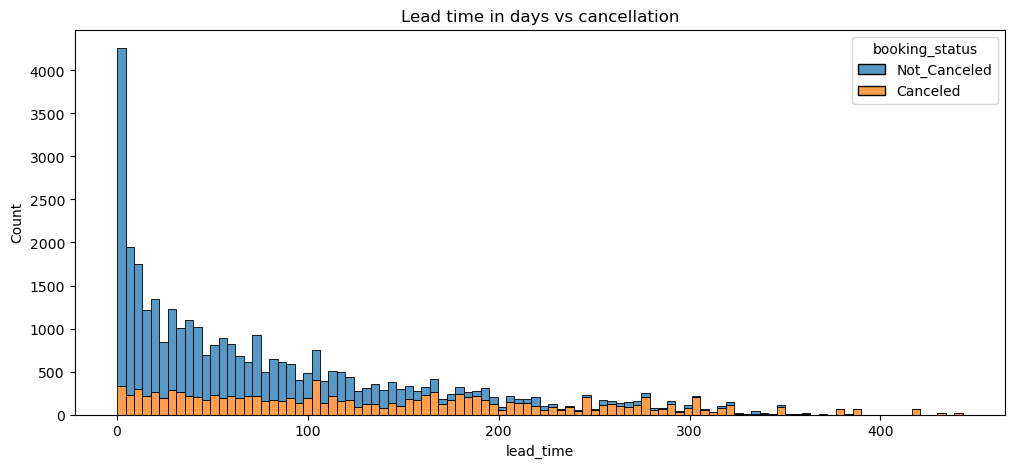

In [24]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='lead_time', hue='booking_status', bins=100, multiple='stack').set_title('Lead time in days vs cancellation')

Guest within 20 days of arrival show up and are less likely to cancel while guest that ariived beyond 100 days are more likely to cancel.

### Market segment and cancellation

Text(0.5, 1.0, 'Market segment type vs cancellation')

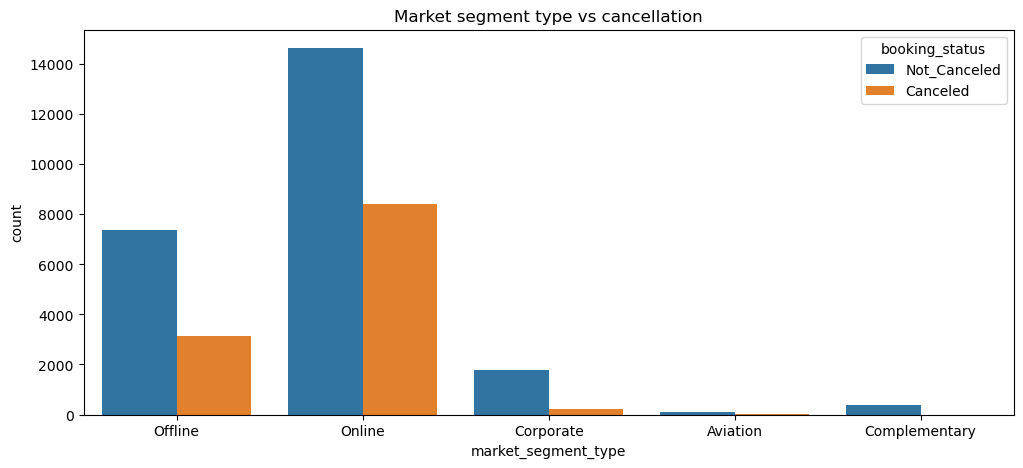

In [25]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='market_segment_type', hue='booking_status').set_title('Market segment type vs cancellation')

Online booking result to very high chance of cancelling while the offline booking is stil moderate but still high. 

Text(0.5, 1.0, 'No of previous bookings not canceled vs cancellation')

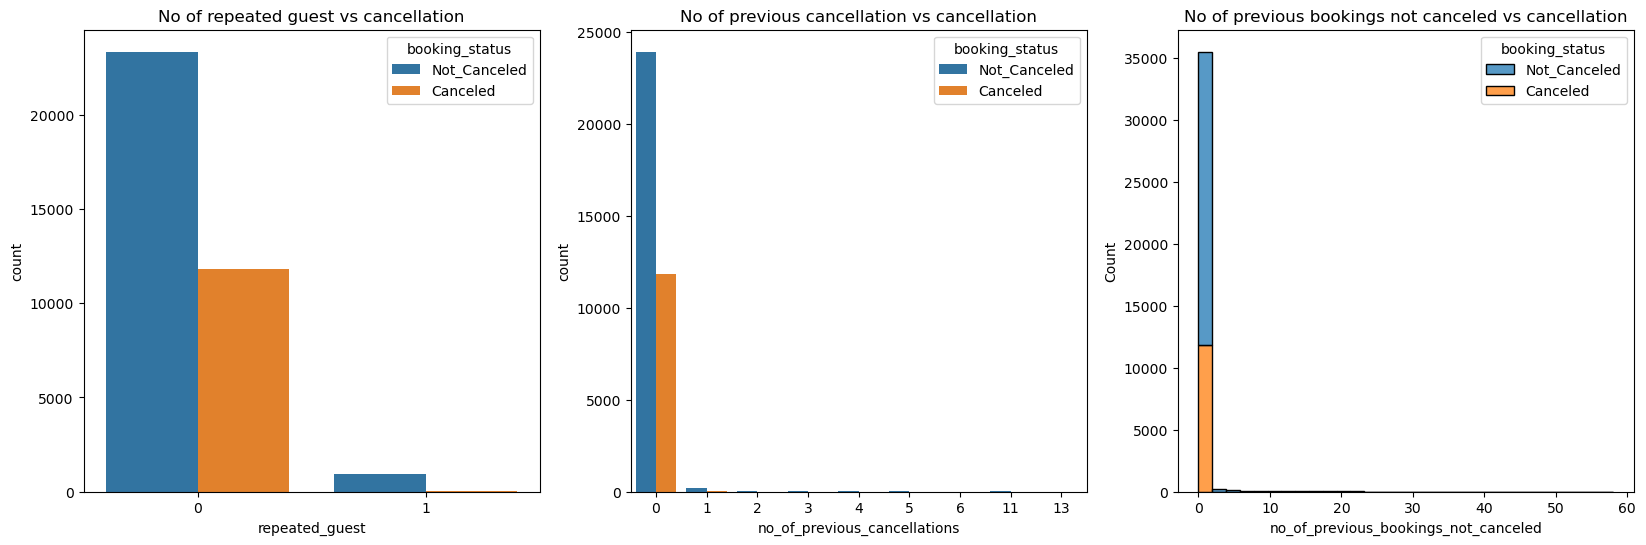

In [26]:
fig, ax = plt.subplots(1,3, figsize=(20,6))

# repeated guest
sns.countplot(data=df, x='repeated_guest', hue='booking_status', ax=ax[0]).set_title('No of repeated guest vs cancellation')

# previously cancelled bookings
sns.countplot(data=df, x='no_of_previous_cancellations', hue='booking_status', ax=ax[1]).set_title('No of previous cancellation vs cancellation')

# previously non-cancelled bookings 
sns.histplot(data=df, x='no_of_previous_bookings_not_canceled', hue='booking_status', ax=ax[2], bins=30, multiple='stack').set_title('No of previous bookings not canceled vs cancellation')

New guest cancel at significantly high rate than returning guest. 

### Guest previous experience with the hotel and cancellation

Text(0.5, 1.0, 'Average price per room')

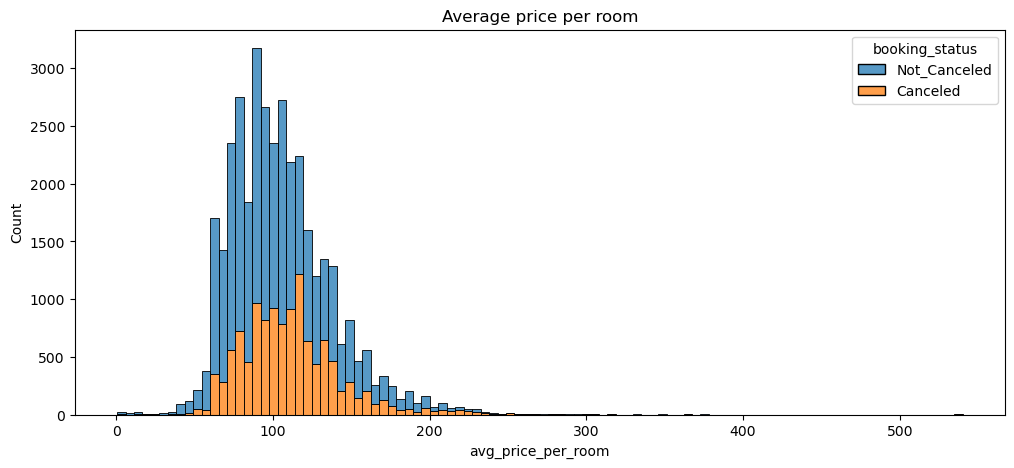

In [27]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='avg_price_per_room', hue='booking_status', multiple='stack', bins=100).set_title('Average price per room')

The most expensive rooms are the most reliable booking because they have low rate of cancellations. This rooms might be for occassional puroses like honeymoon, anniversary and the likes.


## Data processing 2

#### Remove outliers 

In [28]:
#columns for outlier removal
cols = ['lead_time', 'avg_price_per_room']

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

#removing outliers
df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

#### Import model libraries

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from category_encoders import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report


#### Label Encoding

In [30]:
le = LabelEncoder()

cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']

for col in cols:
    le.fit(df[col])
    df[col] = le.transform(df[col])
    print(col, df[col].unique())

# encoders = {}

# for col in cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     encoders[col] = le

type_of_meal_plan [0 3 1 2]
room_type_reserved [0 3 5 4 1 6 2]
market_segment_type [3 4 2 0 1]
booking_status [1 0]


#### Correlation Map 

<Axes: >

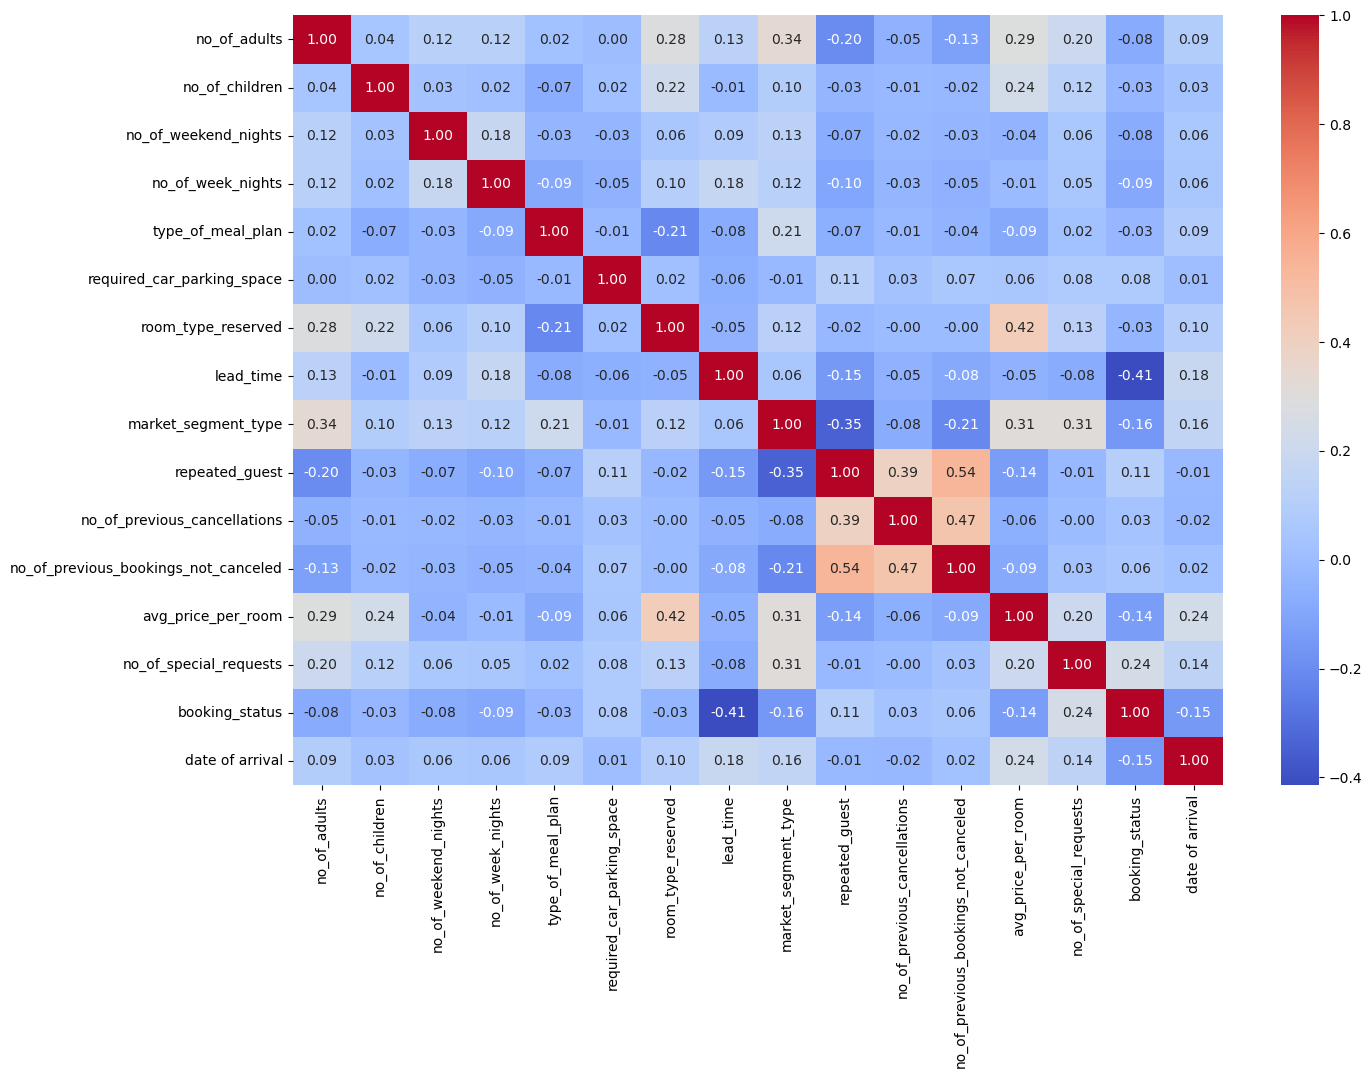

In [31]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [32]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'market_segment_type',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'date of arrival'],
      dtype='object')

#### Split data

In [33]:
# date of arrival is giving the model problem so we drop before spliting the data.
df.drop(columns='date of arrival', inplace=True)
df.columns
df.dtypes

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                         int64
required_car_parking_space                int64
room_type_reserved                        int64
lead_time                                 int64
market_segment_type                       int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                            int64
dtype: object

In [34]:
# features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
#        'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
#        'room_type_reserved', 'lead_time', 'market_segment_type',
#        'repeated_guest', 'no_of_previous_cancellations',
#        'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
#        'no_of_special_requests', 'date of arrival']
# target = ['booking_status']

# X_train = df[features]
# y_train = df[target]


X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='booking_status', axis=1), df['booking_status'],  test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(26900, 14)
(26900,)
(6725, 14)
(6725,)


### Build Model

In [35]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced')
)

model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [36]:
y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7689219330855018
              precision    recall  f1-score   support

           0       0.60      0.78      0.68      2101
           1       0.89      0.76      0.82      4624

    accuracy                           0.77      6725
   macro avg       0.74      0.77      0.75      6725
weighted avg       0.80      0.77      0.78      6725



In [37]:
import joblib 
joblib.dump(model, 'model.pkl')

['model.pkl']

In [38]:
print(X_test.dtypes)

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                         int64
required_car_parking_space                int64
room_type_reserved                        int64
lead_time                                 int64
market_segment_type                       int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
dtype: object


In [44]:
print(X_test.columns)

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'market_segment_type',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests'],
      dtype='object')
